# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [7]:
## The following libraries might be useful
# !pip install -U -q langchain-community          # document loaders
# !pip install -U -q langchain-huggingface        # local embedding model
# !pip install -U -q langchain-chroma             # vector database
# !pip install -U -q langchain-google-genai       # Gemini, used for generation and the Ragas judge
# !pip install -U -q python-dotenv                # reads the API key from .env
# !pip install -U -q ragas                        # RAG evaluation
# !pip install -U -q rapidfuzz                    # required by the non-LLM retrieval metrics

In [58]:
# Import essential libraries

import os, re, json, random, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")          # before langchain imports (community warns on import)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)



#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [59]:
# Load the files as documents

DATA_DIR = Path("rag_legal")
CORPUS_DIR = DATA_DIR / "corpus"
BENCHMARK_DIR = DATA_DIR / "benchmarks"
CORPORA = ["contractnli", "cuad", "maud", "privacy_qa"]

print("Corpus files found:", len(list(CORPUS_DIR.rglob("*.txt"))))

# DirectoryLoader and TextLoader => document loaders provided by the LangChain community.
documents = []
n_files = len(list(CORPUS_DIR.rglob("*.txt")))
print("Corpus .txt files on disk:", n_files)

for corpus in CORPORA:
    loader = DirectoryLoader(
        str(CORPUS_DIR / corpus),
        glob="**/*.txt",
        loader_cls=TextLoader,
        loader_kwargs={"autodetect_encoding": True},   # falls back if a file isn't utf-8
        show_progress=True,
    )
    docs = loader.load()

    # TextLoader only sets metadata['source']. These extra
    # fields are for traceability and are relied on later:
    #   corpus     -> group-by for the EDA in section 1.3
    #   file_path  -> mirrors the benchmark's file_path format, so retrieved chunks
    #                 can be matched to ground truth in section 3
    for doc in docs:
        src = Path(doc.metadata["source"])
        doc.metadata["corpus"] = corpus
        doc.metadata["file_name"] = src.name
        doc.metadata["file_path"] = str(src.relative_to(CORPUS_DIR))

    documents.extend(docs)
    print(f"{corpus:12s}: {len(docs):3d} documents")


# DirectoryLoader returns files in arbitrary order - sort for reproducibility
documents = sorted(documents, key=lambda d: d.metadata["file_path"])

# verify nothing was silently dropped during loading
assert len(documents) == n_files, f"loaded {len(documents)} but found {n_files} on disk"

print(f"\nTotal documents loaded: {len(documents)}")
documents[0].metadata

Corpus files found: 644
Corpus .txt files on disk: 644


100%|██████████| 93/93 [00:00<00:00, 430.29it/s]


contractnli :  93 documents


100%|██████████| 431/431 [00:01<00:00, 319.26it/s]


cuad        : 431 documents


100%|██████████| 117/117 [00:02<00:00, 52.63it/s]


maud        : 117 documents


100%|██████████| 3/3 [00:00<00:00, 497.07it/s]

privacy_qa  :   3 documents

Total documents loaded: 644


{'source': 'rag_legal/corpus/contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt',
 'corpus': 'contractnli',
 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt',
 'file_path': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt'}

#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [60]:
# Clean and preprocess the data
# ----------------------------------------------------------------------------
# remove special characters, extra whitespace and irrelevant
#   content (email / telephone); normalise text (lowercase, remove stop words);
#   log errors and skip problematic files.
#
# the text is kept in two views, because those requirements serve two
#   different consumers - normalised text is right for counting words (1.3) but
#   would break retrieval (1.4 onwards), since dropping stop words and word
#   order makes "shall not disclose" identical to "shall disclose".
# ----------------------------------------------------------------------------

STOPWORDS = set(stopwords.words("english"))

EMAIL_RE   = re.compile(r"[\w\.\-]+@[\w\.\-]+\.\w+")
PHONE_RE   = re.compile(r"(?:\+?\d{1,3}[\s.\-]?)?\(?\d{3}\)?[\s.\-]?\d{3}[\s.\-]?\d{4}")
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
SPECIAL_RE = re.compile(r"[^A-Za-z0-9\s.,;:()\[\]\-'\"/%$&§]")
SPACE_RE   = re.compile(r"[ \t]+")
NEWLINE_RE = re.compile(r"\n{3,}")

# Unicode variants actually present in this corpus 
# curly quotes ~94k, narrow no-break space ~16k, zero-width space ~1.2k.
# Quotes must be mapped before SPECIAL_RE, else "party's" becomes "party s" and
# defined terms lose the quotes that mark them. Zero-width space maps to "" not
# " ", because it is not whitespace and sits *inside* words.
UNICODE_FIXES = [("\xa0", " "), ("\u202f", " "), ("\u200b", ""),
                 ("“", '"'), ("”", '"'), ("‘", "'"), ("’", "'")]


def clean_text(text):
    """View 1 - for the RAG pipeline: noise removed, readable legal text kept."""
    for src, dst in UNICODE_FIXES:
        text = text.replace(src, dst)

    text = URL_RE.sub(" ", text)        # irrelevant content
    text = EMAIL_RE.sub(" ", text)      # contact info
    text = PHONE_RE.sub(" ", text)      # contact info
    text = SPECIAL_RE.sub(" ", text)    # special characters
    text = SPACE_RE.sub(" ", text)      # extra whitespace

    # collapse blank-line runs but keep paragraph breaks: the text splitter in 1.4
    # tries "\n\n" first, so these boundaries are what keep clauses intact
    text = NEWLINE_RE.sub("\n\n", text)
    return text.strip()


def normalise_text(text):
    """View 2 - for the EDA in 1.3 only: lowercase, no punctuation, no stop words."""
    # digits dropped: the numbers that surface are clause/section numbering
    # ("Section 1", "2.1", "(b)"), i.e. document structure rather than content
    text = re.sub(r"[^a-z\s]", " ", text.lower())

    # len > 1 removes single-letter list markers such as the "b" from "(b)"
    return " ".join(w for w in text.split() if w not in STOPWORDS and len(w) > 1)


# --- apply cleaning; log and skip anything problematic ---
cleaned_documents, skipped = [], []

for doc in tqdm(documents, desc="Cleaning documents"):
    fp = doc.metadata["file_path"]
    try:
        cleaned = clean_text(doc.page_content)

        if not cleaned:
            skipped.append((fp, "empty after cleaning"))
            continue

        # new Document, so `documents` keeps the raw text that the benchmark
        # character spans in Section 3 refer to
        cleaned_documents.append(Document(page_content=cleaned, metadata=doc.metadata))

    except Exception as e:
        skipped.append((fp, f"{type(e).__name__}: {e}"))

# EDA view, aligned index-for-index with cleaned_documents
normalised_texts = [normalise_text(d.page_content)
                    for d in tqdm(cleaned_documents, desc="Normalising for EDA")]

print(f"\nCleaned : {len(cleaned_documents)} documents")
print(f"Skipped : {len(skipped)} documents")
for fp, reason in skipped:
    print("   !", fp, "->", reason)

# before / after preview
print("\n--- RAW        :", repr(documents[0].page_content[:200]))
print("\n--- CLEANED    :", repr(cleaned_documents[0].page_content[:200]))
print("\n--- NORMALISED :", repr(normalised_texts[0][:200]))

Normalising for EDA: 100%|██████████| 644/644 [00:07<00:00, 82.26it/s] 


Cleaned : 644 documents
Skipped : 0 documents

--- RAW        : 'MUTUAL NON-DISCLOSURE AGREEMENT\nBetween\nAND\nSubject Matter:\nEffective Date of Agreement: Period , 2017\nfor Exchange of Information: , 2017 to\nPeriod of Confidentiality:\nTHIS AGREEMENT is made as of th'

--- CLEANED    : 'MUTUAL NON-DISCLOSURE AGREEMENT\nBetween\nAND\nSubject Matter:\nEffective Date of Agreement: Period , 2017\nfor Exchange of Information: , 2017 to\nPeriod of Confidentiality:\nTHIS AGREEMENT is made as of th'

--- NORMALISED : 'mutual non disclosure agreement subject matter effective date agreement period exchange information period confidentiality agreement made effective date agreement noted parties background parties desi'


### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [2 marks] </font>
Calculate the average, maximum and minimum document length.

In [61]:
# Calculate the average, maximum and minimum document length.

lengths = pd.DataFrame({
    "corpus":    [d.metadata["corpus"]    for d in cleaned_documents],
    "file_path": [d.metadata["file_path"] for d in cleaned_documents],
    "n_chars":   [len(d.page_content)         for d in cleaned_documents],
    "n_words":   [len(d.page_content.split()) for d in cleaned_documents],
})

print(f"Documents analysed: {len(lengths)}\n")

print("Document length in CHARACTERS")
print(f"  average : {lengths['n_chars'].mean():>10,.0f}")
print(f"  maximum : {lengths['n_chars'].max():>10,}")
print(f"  minimum : {lengths['n_chars'].min():>10,}")

print("\nDocument length in WORDS")
print(f"  average : {lengths['n_words'].mean():>10,.0f}")
print(f"  maximum : {lengths['n_words'].max():>10,}")
print(f"  minimum : {lengths['n_words'].min():>10,}")

# which documents are the extremes (traceability)
print(f"\nLongest : {lengths.loc[lengths['n_chars'].idxmax(), 'file_path']}")
print(f"Shortest: {lengths.loc[lengths['n_chars'].idxmin(), 'file_path']}")

# per-corpus breakdown
print("\nPer-corpus document length (characters):")
lengths.groupby("corpus")["n_chars"].agg(
    docs="count", mean="mean", min="min", max="max"
).round(0).astype(int)

Documents analysed: 644

Document length in CHARACTERS
  average :     97,042
  maximum :    984,465
  minimum :      1,455

Document length in WORDS
  average :     15,250
  maximum :    156,147
  minimum :        223

Longest : maud/Contango_Oil_&_Gas_KKR_&_Co.txt
Shortest: cuad/GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46-WEB HOSTING AGREEMENT.txt

Per-corpus document length (characters):


,docs,mean,min,max
corpus,,,,
contractnli,93,10553,2366,33302
cuad,431,50278,1455,300185
maud,117,340075,103632,984465
privacy_qa,3,18263,3178,26424


#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurence of words and find the most and least occuring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

Total tokens      : 5,204,619
Vocabulary size   : 27,358


,most_common_word,count,least_common_word,count_
0,company,135777,fyber,1
1,shall,95633,heyzap,1
2,agreement,92941,hyprmx,1
3,section,65908,inmobi,1
4,parent,54884,ironsource,1
5,party,48774,kongregate,1
6,date,34571,lifestreet,1
7,time,31464,loopme,1
8,merger,29835,motive,1
9,material,29439,nativex,1


Words occurring exactly once: 7,889 (28.8% of the vocabulary)


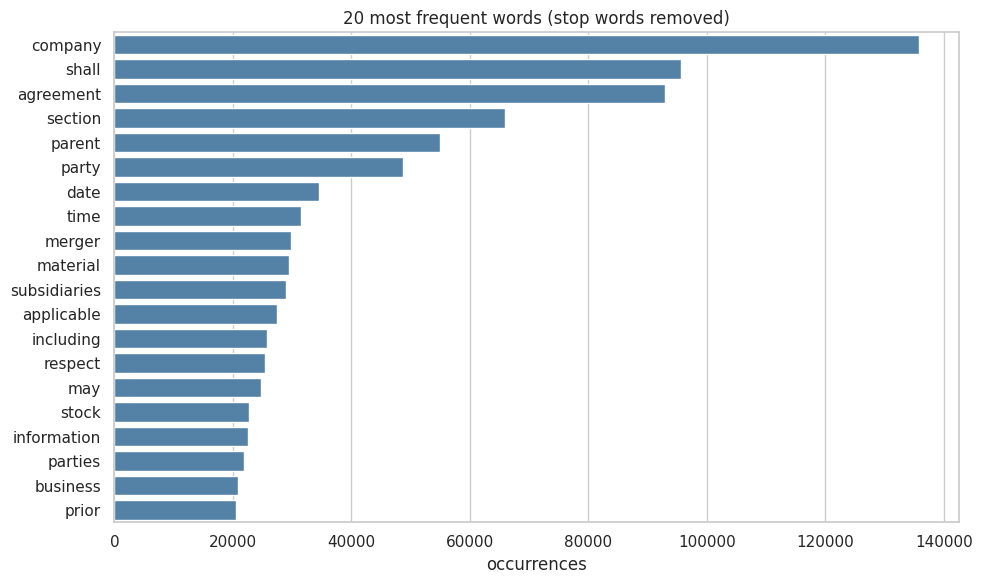

In [62]:
# Find frequency of occurence of words

word_counts = Counter()
for text in normalised_texts:
    word_counts.update(text.split())

print(f"Total tokens      : {sum(word_counts.values()):,}")
print(f"Vocabulary size   : {len(word_counts):,}")

ranked = word_counts.most_common()
most_common, least_common = ranked[:20], ranked[-20:]

freq_df = pd.DataFrame({
    "most_common_word":  [w for w, _ in most_common],
    "count":             [c for _, c in most_common],
    "least_common_word": [w for w, _ in least_common],
    "count_":            [c for _, c in least_common],
})
display(freq_df)

# context for the "least common" result: most of the tail are one-off words
hapax = [w for w, c in ranked if c == 1]
print(f"Words occurring exactly once: {len(hapax):,} "
      f"({len(hapax)/len(word_counts):.1%} of the vocabulary)")

# visualisation of the 20 most frequent words
plt.figure(figsize=(10, 6))
sns.barplot(x=[c for _, c in most_common], y=[w for w, _ in most_common], color="steelblue")
plt.title("20 most frequent words (stop words removed)")
plt.xlabel("occurrences"); plt.ylabel("")
plt.tight_layout()
plt.show()

#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

TF-IDF matrix shape : (644, 14767)
Documents           : 644
TF-IDF features     : 14767

Similarity matrix shape: (644, 644)


,0,1,2,3,4,5,6,7,8,9
0 contractnli 01_Bosch-Automotive-Service-Solution,1.00,0.33,0.23,0.28,0.24,0.31,0.26,0.26,0.14,0.17
1 contractnli 5-NSK-Confidentiality-Agreement-for-,0.33,1.00,0.24,0.24,0.29,0.48,0.25,0.29,0.10,0.15
2 contractnli ADVANIDE-NON-DISCLOSURE-AGREEMENT.tx,0.23,0.24,1.00,0.20,0.17,0.21,0.17,0.19,0.08,0.13
3 contractnli AGProjects-NDA.txt,0.28,0.24,0.20,1.00,0.20,0.20,0.18,0.21,0.09,0.14
4 contractnli AfriGIS_Client-NDA_Template_2019.txt,0.24,0.29,0.17,0.20,1.00,0.29,0.17,0.30,0.10,0.14
5 contractnli Aspiegel_NDA_template.txt,0.31,0.48,0.21,0.20,0.29,1.00,0.20,0.29,0.10,0.14
6 contractnli BCG-Mutual-NDA.txt,0.26,0.25,0.17,0.18,0.17,0.20,1.00,0.18,0.11,0.13
7 contractnli BT_NDA.txt,0.26,0.29,0.19,0.21,0.30,0.29,0.18,1.00,0.10,0.16
8 contractnli CBP%20Non-Disclosure%20Form_October2,0.14,0.10,0.08,0.09,0.10,0.10,0.11,0.10,1.00,0.07
9 contractnli CopAcc_NDA-and-ToP-Mentors_2.0_2017.,0.17,0.15,0.13,0.14,0.14,0.14,0.13,0.16,0.07,1.00


Off-diagonal similarity - mean 0.197, min 0.071, max 0.479

5 most similar pairs:
  0.479  contractnli/5-NSK-Confidentiality-Agreement-for-Suppliers.txt
         contractnli/Aspiegel_NDA_template.txt
  0.331  contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt
         contractnli/5-NSK-Confidentiality-Agreement-for-Suppliers.txt
  0.312  contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt
         contractnli/Aspiegel_NDA_template.txt
  0.296  contractnli/AfriGIS_Client-NDA_Template_2019.txt
         contractnli/BT_NDA.txt
  0.291  contractnli/Aspiegel_NDA_template.txt
         contractnli/BT_NDA.txt


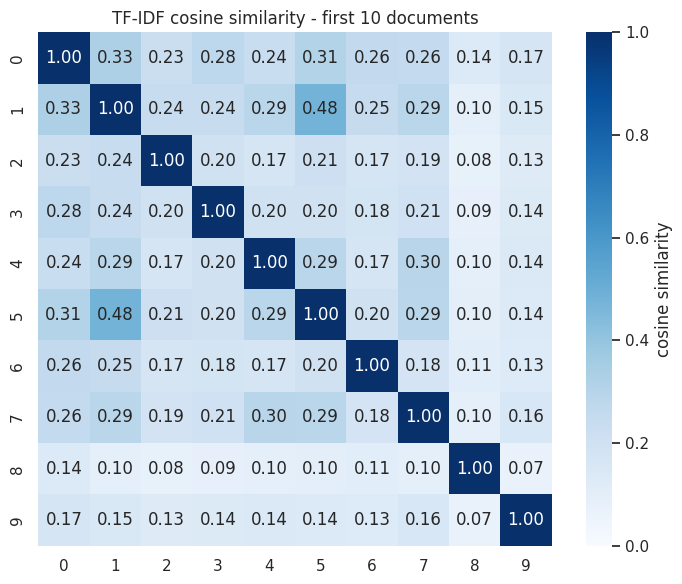

In [63]:
# Transform the page contents of documents
# ----------------------------------------------------------------------------
# fitted on ALL 644 documents, not just the 10 being compared: IDF is a
# corpus-level statistic, so "confidential" only looks unremarkable once the
# vectoriser has seen every contract.
# input is `normalised_texts` from 1.2.2 (lowercased, stop words removed) -
# TF-IDF is bag-of-words, so the word order that view drops costs nothing here.
# ----------------------------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_df=0.95,        # ignore terms in >95% of documents - boilerplate separates nothing
    min_df=2,           # ignore terms in only one document (28.8% of the vocabulary - 1.3.2)
    sublinear_tf=True,  # 1 + log(tf): drafting repeats defined terms dozens of times
)
tfidf_matrix = vectorizer.fit_transform(normalised_texts)

print("TF-IDF matrix shape :", tfidf_matrix.shape)
print("Documents           :", tfidf_matrix.shape[0])
print("TF-IDF features     :", tfidf_matrix.shape[1])

# Compute similarity scores
# ----------------------------------------------------------------------------
# cosine, not Euclidean: documents run from 1,455 to 984,465 characters (1.3.1),
# so a length-sensitive metric would mostly measure size. Cosine compares the
# angle, i.e. the mix of terms.   cosine distance = 1 - cosine similarity.
# the full 644 x 644 matrix is only ~3 MB, so compute it once and slice it.
# ----------------------------------------------------------------------------

similarity_matrix = cosine_similarity(tfidf_matrix)
print("\nSimilarity matrix shape:", similarity_matrix.shape)


def report_similarity(indices, title, top_n=5):
    """Slice the similarity matrix for `indices` and report the near-duplicates."""
    sim = similarity_matrix[np.ix_(indices, indices)]

    display(pd.DataFrame(
        sim.round(2), columns=indices,
        index=[f"{i:>3}  {cleaned_documents[i].metadata['corpus']:11s}  "
               f"{cleaned_documents[i].metadata['file_name'][:36]}" for i in indices],
    ))

    # the diagonal is always 1.0, so only the upper triangle describes the sample
    off_diag = sim[np.triu_indices(len(indices), k=1)]
    print(f"Off-diagonal similarity - mean {off_diag.mean():.3f}, "
          f"min {off_diag.min():.3f}, max {off_diag.max():.3f}")

    pairs = sorted(((sim[a, b], indices[a], indices[b])
                    for a in range(len(indices))
                    for b in range(a + 1, len(indices))), reverse=True)

    print(f"\n{top_n} most similar pairs:")
    for score, i, j in pairs[:top_n]:
        print(f"  {score:.3f}  {cleaned_documents[i].metadata['file_path']}")
        print(f"         {cleaned_documents[j].metadata['file_path']}")

    plt.figure(figsize=(7.5, 6))
    sns.heatmap(sim, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=indices, yticklabels=indices, square=True,
                cbar_kws={"label": "cosine similarity"})
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return sim


first_10 = list(range(10))
sim_first = report_similarity(first_10, "TF-IDF cosine similarity - first 10 documents")

In [64]:
# create a list of 10 random integers
random.seed(42)
np.random.seed(42)
random_10 = sorted(random.sample(range(len(cleaned_documents)), 10))

print("Random document indices:", random_10)
print("\nCorpus mix of the sample:")
print(pd.Series([cleaned_documents[i].metadata["corpus"] for i in random_10]).value_counts())

print("\nDocuments sampled:")
for i in random_10:
    print(f"  {i:>3}  {cleaned_documents[i].metadata['file_path']}")

Random document indices: [25, 89, 104, 114, 142, 228, 250, 281, 558, 604]

Corpus mix of the sample:
cuad           6
contractnli    2
maud           2
Name: count, dtype: int64

Documents sampled:
   25  contractnli/IGC-Non-Disclosure-Agreement-LSE-Sample.txt
   89  contractnli/thoughtbot-mutual-nda.txt
  104  cuad/AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.txt
  114  cuad/ATMOSENERGYCORP_11_22_2002-EX-10.17-TRANSPORTATION SERVICE AGREEMENT.txt
  142  cuad/BLACKBOXSTOCKSINC_08_05_2014-EX-10.1-DISTRIBUTOR AGREEMENT.txt
  228  cuad/Freecook_20180605_S-1_EX-10.3_11233807_EX-10.3_Hosting Agreement.txt
  250  cuad/GluMobileInc_20070319_S-1A_EX-10.09_436630_EX-10.09_Content License Agreement3.txt
  281  cuad/INKTOMICORP_06_08_1998-EX-10.14-SOFTWARE HOSTING AGREEMENT.txt
  558  maud/Eidos Therapeutics, Inc._BridgeBio Pharma, Inc..txt
  604  maud/Pandion Therapeutics, Inc._Merck _ Co., Inc..txt


,25,89,104,114,142,228,250,281,558,604
25 contractnli IGC-Non-Disclosure-Agreement-LSE-Sam,1.00,0.23,0.22,0.09,0.21,0.07,0.04,0.21,0.24,0.25
89 contractnli thoughtbot-mutual-nda.txt,0.23,1.00,0.21,0.05,0.17,0.08,0.04,0.17,0.17,0.17
104 cuad AIRTECHINTERNATIONALGROUPINC_05_08_2,0.22,0.21,1.00,0.12,0.30,0.13,0.08,0.32,0.35,0.39
114 cuad ATMOSENERGYCORP_11_22_2002-EX-10.17-,0.09,0.05,0.12,1.00,0.12,0.05,0.03,0.10,0.11,0.12
142 cuad BLACKBOXSTOCKSINC_08_05_2014-EX-10.1,0.21,0.17,0.30,0.12,1.00,0.10,0.06,0.25,0.26,0.26
228 cuad Freecook_20180605_S-1_EX-10.3_112338,0.07,0.08,0.13,0.05,0.10,1.00,0.04,0.17,0.11,0.12
250 cuad GluMobileInc_20070319_S-1A_EX-10.09_,0.04,0.04,0.08,0.03,0.06,0.04,1.00,0.07,0.07,0.07
281 cuad INKTOMICORP_06_08_1998-EX-10.14-SOFT,0.21,0.17,0.32,0.10,0.25,0.17,0.07,1.00,0.30,0.32
"558 maud Eidos Therapeutics, Inc._BridgeBio P",0.24,0.17,0.35,0.11,0.26,0.11,0.07,0.30,1.00,0.68
"604 maud Pandion Therapeutics, Inc._Merck _ C",0.25,0.17,0.39,0.12,0.26,0.12,0.07,0.32,0.68,1.00


Off-diagonal similarity - mean 0.171, min 0.030, max 0.680

5 most similar pairs:
  0.680  maud/Eidos Therapeutics, Inc._BridgeBio Pharma, Inc..txt
         maud/Pandion Therapeutics, Inc._Merck _ Co., Inc..txt
  0.391  cuad/AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.txt
         maud/Pandion Therapeutics, Inc._Merck _ Co., Inc..txt
  0.354  cuad/AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.txt
         maud/Eidos Therapeutics, Inc._BridgeBio Pharma, Inc..txt
  0.323  cuad/AIRTECHINTERNATIONALGROUPINC_05_08_2000-EX-10.4-FRANCHISE AGREEMENT.txt
         cuad/INKTOMICORP_06_08_1998-EX-10.14-SOFTWARE HOSTING AGREEMENT.txt
  0.321  cuad/INKTOMICORP_06_08_1998-EX-10.14-SOFTWARE HOSTING AGREEMENT.txt
         maud/Pandion Therapeutics, Inc._Merck _ Co., Inc..txt


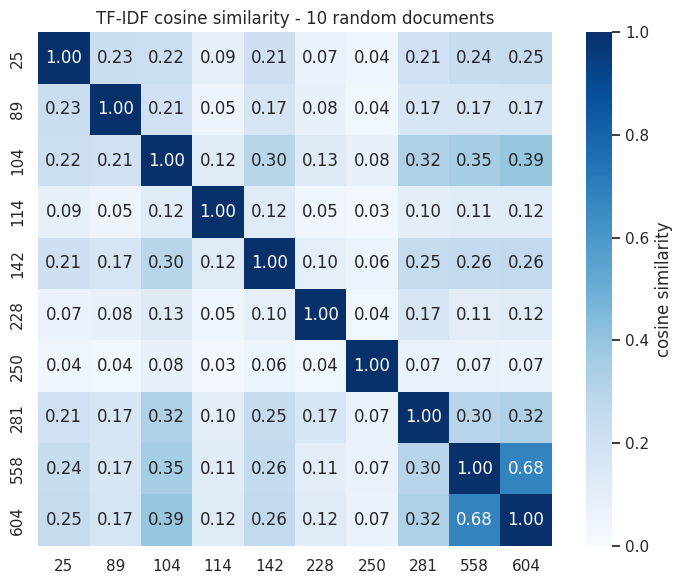


Distribution of the 45 off-diagonal similarities in each sample:


,first 10 (all contractnli),random 10 (mixed corpora)
mean,0.197,0.171
std,0.082,0.123
min,0.071,0.030
50%,0.186,0.128
max,0.479,0.680


In [65]:
# Compute similarity scores for 10 random documents

sim_random = report_similarity(random_10, "TF-IDF cosine similarity - 10 random documents")

# the two samples side by side - this comparison is what the question asks about
comparison = pd.DataFrame({
    "first 10 (all contractnli)": pd.Series(sim_first[np.triu_indices(10, k=1)]).describe(),
    "random 10 (mixed corpora)":  pd.Series(sim_random[np.triu_indices(10, k=1)]).describe(),
}).loc[["mean", "std", "min", "50%", "max"]].round(3)

print("\nDistribution of the 45 off-diagonal similarities in each sample:")
display(comparison)

**Observations**

- We compared documents by their word fingerprints (TF-IDF) using cosine similarity, where 0 means
  nothing in common and 1 means identical.

- **The first 10 documents are all NDAs**, and they score only ~0.2 against each other. TF-IDF
  ignores the wording all contracts share, so what's left is each contract's distinctive vocabulary
  — and two NDAs about different companies don't share much of that. Roughly 0.2 is just the
  background level for "both are legal documents".

- **The 10 random documents are a mix of contract types, and mostly score even lower** (median 0.13).
  A couple have their own private vocabulary and match nothing: document 250 (a games content
  licence) scores at most 0.08 against anything else.

- **One pair stands out: documents 558 and 604 at 0.68** — the two merger agreements
  (Eidos/BridgeBio and Pandion/Merck). They share large amounts of text. This is the "highly similar clauses" case the task asked us to
  detect, and the method found it with no legal knowledge.

- **Nothing scores near 1.0**, so there are no duplicate documents to remove. But since contracts
  are mostly shared boilerplate that differ in only a small part of their text, searching whole
  documents would be useless — we need to split them into clause-sized chunks (1.4) and keep a
  label on each chunk saying which contract it came from.


### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

Documents in  : 644
Chunks out    : 91,116   (dropped 7,630 under 50 chars)
Chunks per document: mean 141, max 1,446

Chunk length in characters:
  mean    714   median    786   min   50   max  1000

Chunks per corpus:
corpus
maud           58747
cuad           30908
contractnli     1393
privacy_qa        68
Name: count, dtype: int64


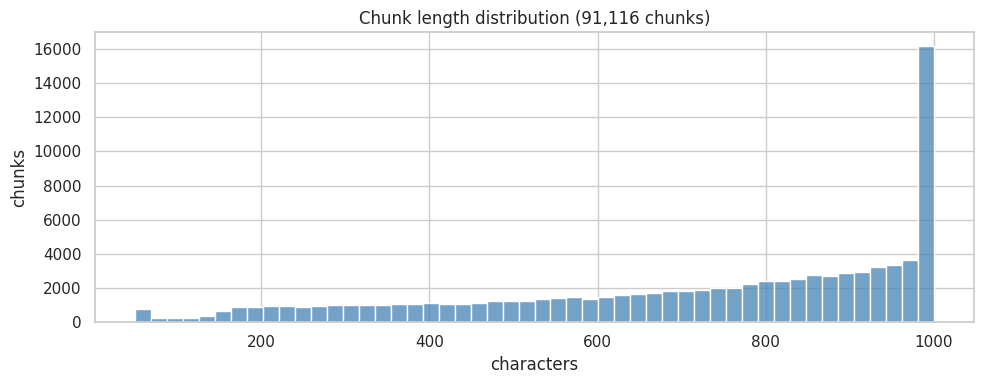

--- Sample chunk ---
metadata: {'source': 'rag_legal/corpus/contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'corpus': 'contractnli', 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'file_path': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'start_index': 3718, 'chunk_index': 5, 'chunk_id': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt::5'}

 3. TERM. The term of this Agreement shall be for the Period of Exchange set forth above. Confidentiality obligations shall survive termination of this Agreement for the Period of Confidentiality set forth above unless the Confidential Information is a trade secret, in which case the confidentiality obligations shall continue for as long as the information is a trade secret. Either party may termin ...
Chunks per document: mean 141, max 1,446

Chunk lengt

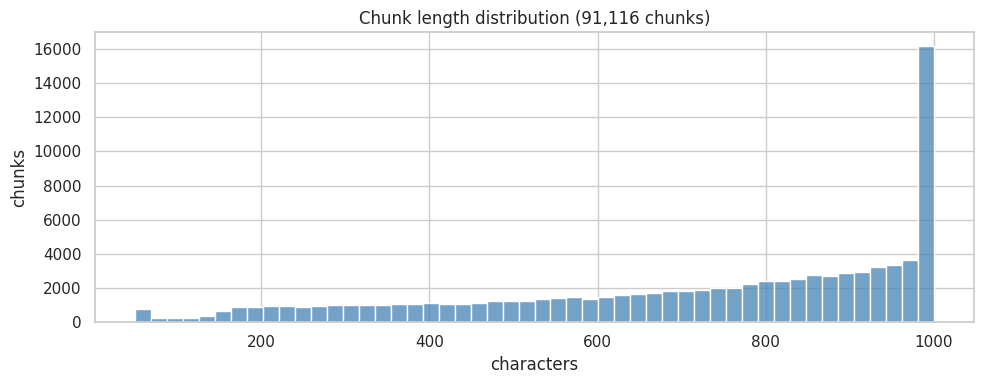

--- Sample chunk ---
metadata: {'source': 'rag_legal/corpus/contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'corpus': 'contractnli', 'file_name': '01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'file_path': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt', 'start_index': 3718, 'chunk_index': 5, 'chunk_id': 'contractnli/01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt::5'}

 3. TERM. The term of this Agreement shall be for the Period of Exchange set forth above. Confidentiality obligations shall survive termination of this Agreement for the Period of Confidentiality set forth above unless the Confidential Information is a trade secret, in which case the confidentiality obligations shall continue for as long as the information is a trade secret. Either party may termin ...


In [66]:
# Process files and generate chunks

# ----------------------------------------------------------------------------
# why chunk: 1.3.3 showed documents overlap heavily in boilerplate and differ in only
#   a small part of their text, so whole-document retrieval cannot discriminate between
#   them. Retrieval has to happen at clause level.
# also unavoidable: the longest document is 984,465 characters (1.3.1), far beyond any
#   embedding model's context window - it could not be embedded as one vector.
#
# input is `cleaned_documents`, NOT `normalised_texts`: retrieval needs real word order
#   and stop words ("shall not disclose" vs "shall disclose").
# ----------------------------------------------------------------------------

CHUNK_SIZE = 1000       # characters - roughly one clause plus context
CHUNK_OVERLAP = 150     # 15% - keeps a clause intact if it straddles a boundary
MIN_CHUNK_CHARS = 50    # below this a chunk is a stray heading, not retrievable content

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    # tried in order: paragraph -> line -> sentence -> word -> character.
    # the paragraph breaks were deliberately preserved by the cleaning in 1.2.2,
    # so the splitter can cut on clause boundaries before falling back to anything cruder
    separators=["\n\n", "\n", ". ", " ", ""],
    add_start_index=True,   # character offset of the chunk within its cleaned document
)

chunks = splitter.split_documents(cleaned_documents)

# drop fragments too small to retrieve on
too_small = [c for c in chunks if len(c.page_content) < MIN_CHUNK_CHARS]
chunks = [c for c in chunks if len(c.page_content) >= MIN_CHUNK_CHARS]

# stable identifier per chunk - needed to trace an answer back to its contract in section 3
seen = Counter()
for c in chunks:
    fp = c.metadata["file_path"]
    c.metadata["chunk_index"] = seen[fp]
    c.metadata["chunk_id"] = f"{fp}::{seen[fp]}"
    seen[fp] += 1


# --- report ---
chunk_lengths = pd.Series([len(c.page_content) for c in chunks])

print(f"Documents in  : {len(cleaned_documents):,}")
print(f"Chunks out    : {len(chunks):,}   (dropped {len(too_small):,} under {MIN_CHUNK_CHARS} chars)")
print(f"Chunks per document: mean {len(chunks) / len(cleaned_documents):.0f}, max {max(seen.values()):,}")

print(f"\nChunk length in characters:")
print(f"  mean {chunk_lengths.mean():>6.0f}   median {chunk_lengths.median():>6.0f}"
      f"   min {chunk_lengths.min():>4}   max {chunk_lengths.max():>5}")

by_corpus = pd.DataFrame({"corpus": [c.metadata["corpus"] for c in chunks]})
print("\nChunks per corpus:")
print(by_corpus["corpus"].value_counts())

plt.figure(figsize=(10, 4))
sns.histplot(chunk_lengths, bins=50, color="steelblue")
plt.title(f"Chunk length distribution ({len(chunks):,} chunks)")
plt.xlabel("characters"); plt.ylabel("chunks")
plt.tight_layout()
plt.show()

# preview
print("--- Sample chunk ---")
print("metadata:", chunks[5].metadata)
print("\n", chunks[5].page_content[:400], "...")

print(f"Chunks per document: mean {len(chunks) / len(cleaned_documents):.0f}, max {max(seen.values()):,}")

print(f"\nChunk length in characters:")
print(f"  mean {chunk_lengths.mean():>6.0f}   median {chunk_lengths.median():>6.0f}"
      f"   min {chunk_lengths.min():>4}   max {chunk_lengths.max():>5}")

by_corpus = pd.DataFrame({"corpus": [c.metadata["corpus"] for c in chunks]})
print("\nChunks per corpus:")
print(by_corpus["corpus"].value_counts())

plt.figure(figsize=(10, 4))
sns.histplot(chunk_lengths, bins=50, color="steelblue")
plt.title(f"Chunk length distribution ({len(chunks):,} chunks)")
plt.xlabel("characters"); plt.ylabel("chunks")
plt.tight_layout()
plt.show()

# preview
print("--- Sample chunk ---")
print("metadata:", chunks[5].metadata)
print("\n", chunks[5].page_content[:400], "...")


## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using an embedding model. You can also use this function to transform during vector DB creation itself.

In [67]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)
from dotenv import load_dotenv
load_dotenv(override=True)
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
# embeddings and the vector DB run locally and need no key; the key is for
# generation in 2.2 and the Ragas judge in 3.1
print("GOOGLE_API_KEY loaded:", bool(GOOGLE_API_KEY))

GOOGLE_API_KEY loaded: True


In [68]:
# Initialise an embedding function
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedding_function = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},          # no GPU on this machine
    # normalised vectors make cosine similarity a plain dot product, and match the
    # cosine distance the Chroma collection is configured with in 2.1.2
    encode_kwargs={"normalize_embeddings": True, "batch_size": 64},
)

# --- verify the function works and discriminates sensibly ---
query = "What is the term of the confidentiality obligation?"
q_vec = np.array(embedding_function.embed_query(query))

relevant   = "The obligations of confidentiality shall survive for a period of five (5) years from the Effective Date."
irrelevant = "The Company shall pay a royalty of eight percent on net revenues from licensed content."
r_vec, i_vec = map(np.array, embedding_function.embed_documents([relevant, irrelevant]))

print(f"Model      : {EMBEDDING_MODEL}")
print(f"Dimensions : {len(q_vec)}")
print(f"Normalised : {np.linalg.norm(q_vec):.3f}   (should be 1.000)")
print("\nSanity check - similarity of the query to:")
print(f"  a confidentiality-term clause : {q_vec @ r_vec:.3f}")
print(f"  an unrelated royalty clause   : {q_vec @ i_vec:.3f}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model      : sentence-transformers/all-MiniLM-L6-v2
Dimensions : 384
Normalised : 1.000   (should be 1.000)

Sanity check - similarity of the query to:
  a confidentiality-term clause : 0.575
  an unrelated royalty clause   : 0.247



**Observation — choice of embedding model**

- We use `all-MiniLM-L6-v2`, the general-purpose model used throughout this module. 
- A QA-tuned alternative of the same size, `multi-qa-MiniLM-L6-cos-v1`, scored the clause that actually answered a test question at 0.68 versus 0.58, and ranked it correctly above a merely topically-similar clause where `all-MiniLM` did not.
- We stay with `all-MiniLM-L6-v2` for consistency with the module pipeline, accepting slightly weaker retrieval as a result.

#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [69]:
import shutil

# vector DB settings, defined here so the rebuild guard below can reference them
PERSIST_DIR     = "chroma_legal_db"   # accessible persist directory for the vector DB
COLLECTION_NAME = "legal_documents"   # Chroma requires 3-512 chars from [a-zA-Z0-9._-]
BATCH_SIZE      = 2000                # well under Chroma's ceiling of 5,461 per add

REBUILD = False   # set True if EMBEDDING_MODEL or the 1.4 chunk settings changed

if REBUILD and Path(PERSIST_DIR).exists():
    shutil.rmtree(PERSIST_DIR)
    print(f"Removed {PERSIST_DIR} - rebuilding from scratch")

In [70]:
# Add Chunks to vector DB
# PERSIST_DIR, COLLECTION_NAME and BATCH_SIZE are set in the cell above

vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embedding_function,
    persist_directory=PERSIST_DIR,
    collection_metadata={"hnsw:space": "cosine"},
)

# resume: skip anything already embedded by a previous run
already_indexed = set(vector_store.get(include=[])["ids"])
pending = [c for c in chunks if c.metadata["chunk_id"] not in already_indexed]

print(f"Persist directory : {Path(PERSIST_DIR).resolve()}")
print(f"Chunks total      : {len(chunks):,}")
print(f"Already indexed   : {len(already_indexed):,}")
print(f"To embed now      : {len(pending):,}  (~{len(pending) / 15 / 60:.0f} min at ~15 chunks/sec)")

for i in tqdm(range(0, len(pending), BATCH_SIZE), desc="Indexing"):
    batch = pending[i:i + BATCH_SIZE]
    vector_store.add_documents(documents=batch, ids=[c.metadata["chunk_id"] for c in batch])

print(f"\nVectors in collection: {vector_store._collection.count():,}")


# --- verify the database actually answers a query ---
# note: with hnsw:space=cosine, Chroma returns cosine DISTANCE (lower is better),
# so similarity = 1 - distance
test_query = "What is the term of the confidentiality obligation?"

print(f"\nTest query: {test_query}\n")
for doc, distance in vector_store.similarity_search_with_score(test_query, k=3):
    print(f"  similarity {1 - distance:.3f}   {doc.metadata['file_path']}")
    print(f"     {doc.page_content[:160].strip()} ...\n")


Persist directory : /home/navneet/projects/python/Revision/C8-GenAI/assignment/chroma_legal_db
Chunks total      : 91,116
Already indexed   : 91,116
To embed now      : 0  (~0 min at ~15 chunks/sec)


Indexing: 0it [00:00, ?it/s]


Vectors in collection: 91,116

Test query: What is the term of the confidentiality obligation?



  similarity 0.845   cuad/EhaveInc_20190515_20-F_EX-4.44_11678816_EX-4.44_License Agreement_ Reseller Agreement.txt
     13. CONFIDENTIALITY (a) Obligation: Each Party acknowledges that all Confidential Information consists of confidential and proprietary information of the disclo ...

  similarity 0.775   cuad/CoherusBiosciencesInc_20200227_10-K_EX-10.29_12021376_EX-10.29_Development Agreement.txt
     11.1 Obligation of Confidentiality. As of and after the Effective Date, all Confidential Information disclosed, revealed or otherwise made available to one Part ...

  similarity 0.759   contractnli/Model%20NDA%20(recommended%20by%20SWA).txt
     Confidential Information (defined below and hereinafter collectively referred to as Confidential Information), to the Receiving Party/Producer under any circums ...



**Observations**

- 644 documents produced **91,116 chunks**, about 141 per document. Embedding them took
  ~87 minutes on CPU (~17.5 chunks/second), saved to disk as a one-time cost.

- All three top hits for the test query are genuine confidentiality clauses, so retrieval
  is working — it finds relevant text, not just similar-sounding text.

- Scores are **0.76–0.85**, far above the ~0.2 we measured between whole documents in 1.3.3.
  Chunking is the reason: a whole contract averages 97,000 characters, so a single clause is
  about 1% of it and gets drowned out. A 1,000-character chunk *is* the clause, so it matches
  the question directly.

- Retrieval matches on meaning alone and has no idea *which* contract is being asked about.
  The top hit is a confidentiality clause from a reseller licence agreement — right for a
  general question, wrong if a specific NDA was meant.

### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Form the complete RAG pipeline. 

You can either create a chain or directly the pipeline

In [71]:
# Create a RAG chain
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

TOP_K = 5   # ~5,000 characters of context - several clauses without burying the answer

retriever = vector_store.as_retriever(search_kwargs={"k": TOP_K})

# temperature 0: section 3 compares answers against fixed ground truth, so the
# pipeline has to give the same answer on every run
LLM_MODEL = "gemini-3.5-flash-lite"
llm = init_chat_model(f"google_genai:{LLM_MODEL}", temperature=0)
# one-off connectivity check - passed, no need to repeat
# print(llm.invoke("Reply with the single word: ok").text)

RAG_PROMPT = ChatPromptTemplate.from_template(
    """You are a legal research assistant. Answer the question using ONLY the contract
excerpts below. Do not use outside legal knowledge.

Rules:
- If the excerpts do not contain the answer, reply exactly:
  "The provided documents do not contain this information."
- Quote the operative contractual wording where possible.
- Name the source file for each fact you state.
- Be concise: two to four sentences.

Contract excerpts:
{context}

Question: {question}

Answer:"""
)


def format_docs(docs):
    """Flatten retrieved chunks into the prompt, tagged so the model can cite them."""
    return "\n\n---\n\n".join(
        f"[Source: {d.metadata['file_path']}]\n{d.page_content}" for d in docs
    )


# answer generation, given the retrieved documents
answer_chain = (
    RunnablePassthrough.assign(context=lambda x: format_docs(x["context"]))
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

# full pipeline: retrieve, then answer, keeping the sources alongside
rag_chain = RunnableParallel(
    {"context": retriever, "question": RunnablePassthrough()}
).assign(answer=answer_chain)

print("RAG chain built")
print(f"  retriever : Chroma, cosine, top-{TOP_K} of {vector_store._collection.count():,} chunks")
print(f"  generator : {LLM_MODEL} (temperature 0)")
print("  returns   : question, context (source documents), answer")


RAG chain built
  retriever : Chroma, cosine, top-5 of 91,116 chunks
  generator : gemini-3.5-flash-lite (temperature 0)
  returns   : question, context (source documents), answer


#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [72]:
# Create a function for question answering
def answer_question(question, verbose=True):
    """Answer a question from the indexed contracts and return the sources behind it."""
    result = rag_chain.invoke(question)
    retrieved = result["context"]

    payload = {
        "question": question,
        "answer":   result["answer"],
        "contexts": [d.page_content for d in retrieved],          # raw text, for Ragas in 3.1
        "sources":  [d.metadata["file_path"] for d in retrieved],  # for traceability
    }

    if verbose:
        print("QUESTION")
        print(" ", question, "\n")
        print("ANSWER")
        print(" ", payload["answer"], "\n")
        print(f"SOURCES  ({len(retrieved)} retrieved chunks)")
        for i, d in enumerate(retrieved, 1):
            print(f"  {i}. {d.metadata['file_path']}  [chunk {d.metadata['chunk_index']}]")
            print(f"     {d.page_content[:140].strip()} ...")

    return payload


In [73]:
# Example question
question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"
response = answer_question(question)


QUESTION
  Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information? 

ANSWER
  The provided documents do not contain this information. 

SOURCES  (5 retrieved chunks)
  1. contractnli/nda-employee-template.txt  [chunk 3]
     2. Non-Disclosure. A Recipient of Confidential Information under this Agreement shall use the Confidential Information only for the purpose ...
  2. cuad/REGANHOLDINGCORP_03_31_2008-EX-10-LICENSE AND HOSTING AGREEMENT.txt  [chunk 56]
     Disclosure. The Receiving Party may disclose Confidential Information only to its own officers, directors, and employees and to its consulta ...
  3. cuad/CERES,INC_01_25_2012-EX-10.20-Collaboration Agreement.txt  [chunk 212]
     10.2 From receipt to five (5) years after the disclosure of the relevant CONFIDENTIAL INFORMATION, the receiving Party shall not use, except ...
  4. cuad/OMINTO,INC_

In [74]:
found = False
for k in [10, 20, 50, 100]:
    hits = vector_store.similarity_search(question, k=k)
    matches = [(rank, d) for rank, d in enumerate(hits, 1)
               if "CopAcc_NDA-and-ToP-Mentors" in d.metadata["file_path"]]
    found = bool(matches)
    print(f"  k={k:3d}  correct document retrieved: {found}")

    if found:
        print()
        for rank, d in matches:
            print(f"  rank {rank} of {k}")
            print(f"    file        : {d.metadata['file_path']}")
            print(f"    chunk       : {d.metadata['chunk_index']} of that file")
            print(f"    position    : character {d.metadata['start_index']:,} of the cleaned text")
            print(f"    text        : {d.page_content[:200].strip()} ...")
        break

  k= 10  correct document retrieved: False
  k= 20  correct document retrieved: False
  k= 50  correct document retrieved: True

  rank 48 of 50
    file        : contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt
    chunk       : 11 of that file
    position    : character 8,528 of the cleaned text
    text        : Mentor shall not use any Confidential Information for any purpose except to review, assess and help develop the Participants Ideas.
Mentor shall not disclose any Confidential Information to any third ...


In [75]:
# One-off demonstration: does the answer exist if we search deeper?
# This is NOT the pipeline default - see the note below.

deep_retriever = vector_store.as_retriever(search_kwargs={"k": 50})
deep_chain = RunnableParallel(
    {"context": deep_retriever, "question": RunnablePassthrough()}
).assign(answer=answer_chain)      # same prompt, same LLM - only the retriever changes

deep = deep_chain.invoke(question)

print("ANSWER (k=50)\n ", deep["answer"], "\n")

sources = [d.metadata["file_path"] for d in deep["context"]]
target_ranks = [i for i, s in enumerate(sources, 1) if "CopAcc_NDA-and-ToP-Mentors" in s]

ANSWER (k=50)
  The provided documents do not contain this information. 



In [76]:
# The retrieved chunk didn't answer the question. Is the answer elsewhere in the same file,
# just ranked too low to surface? Search inside that one contract only.
TARGET_FILE = "contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt"

hits = vector_store.similarity_search_with_score(
    question, k=20, filter={"file_path": TARGET_FILE}
)
print(f"All chunks of {TARGET_FILE}, ranked against the question:\n")
for rank, (d, dist) in enumerate(hits, 1):
    print(f"  {rank:2d}. similarity {1 - dist:.3f}  chunk {d.metadata['chunk_index']:2d}  "
          f"{d.page_content[:95].strip()}")

All chunks of contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt, ranked against the question:

   1. similarity 0.638  chunk 11  Mentor shall not use any Confidential Information for any purpose except to review, assess and
   2. similarity 0.630  chunk 12  Notwithstanding Mentor's right to assess and rate the Ideas of the Participants, Mentor shall n
   3. similarity 0.612  chunk 14  7 Notice of Required Disclosure
If Mentor is required by mandatory, non-appealable judicial or
   4. similarity 0.603  chunk 17  12 Notification of Unauthorised Use
Mentor shall notify Organiser immediately upon discovery of
   5. similarity 0.573  chunk 10  4 Definition of Confidential Information
"Confidential Information" means any Idea disclosed to
   6. similarity 0.546  chunk 18  14 Miscellaneous
This Agreement shall be binding upon Organiser and Mentor, and their successor
   7. similarity 0.532  chunk 13  (b) return to Organiser and/or Participants all materials furnished by Organiser and/or Par

**Conclusion**

1. At k=50 we did retrieve a chunk from the correct contract (rank 48). Reading it, it covers not
   using or disclosing confidential information — it never says whether the agreement grants any
   rights. So it cannot answer the question.

2. That leaves two possibilities: 
   -  the contract does not address this at all, or 
   - the answer is in a different chunk of the same file that scored too low to be retrieved which is more likely.A n NDA of this kind normally has a clause on rights and ownership.

3. Either way the LLM behaved correctly. Handed a passage that does not answer the question, it
   declined rather than guessing. A person reading the same passage would say the same.

4. If the answer is indeed in a lower-ranked chunk, the problem is ranking, not the prompt or the
   model. Possible fixes:
   - **HyDE (Hypothetical Document Embeddings)** — ask the model to draft the clause that would
     answer the question, and search using that instead of the question itself. The question and
     the contract use different words for the same idea, and a drafted clause bridges the gap.
   - **A question-answering embedding model** such as `multi-qa-MiniLM-L6-cos-v1`, which ranks
     passages by whether they answer a question rather than by what they are about.
   - **Smaller chunks**, so unrelated text in the same chunk does not dilute its score.

## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [77]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
# ----------------------------------------------------------------------------
# structure of each benchmark file:
#   tests: [ { query, snippets: [ { file_path, span, answer } ] } ]
#
# note on "answer": it is the VERBATIM EXCERPT from the contract that answers the
#   question, not a written answer. These benchmarks are retrieval benchmarks, so
#   the excerpts are the ground truth for what should have been retrieved. We use
#   them two ways in 3.1.2:
#     reference_contexts -> what retrieval should have found (per snippet)
#     reference          -> a stand-in ground-truth answer (excerpts joined)
# ----------------------------------------------------------------------------

BENCHMARK_FILES = ["contractnli", "cuad", "maud"]   # privacy_qa.json is not present - see below

benchmark_rows = []
for name in BENCHMARK_FILES:
    tests = json.loads((BENCHMARK_DIR / f"{name}.json").read_text())["tests"]
    for t in tests:
        benchmark_rows.append({
            "corpus":       name,
            "question":     t["query"],
            "excerpts":     [s["answer"] for s in t["snippets"]],
            "source_files": sorted({s["file_path"] for s in t["snippets"]}),
        })
    print(f"{name:12s}: {len(tests):5,d} questions")

benchmark = pd.DataFrame(benchmark_rows)

# the evaluation sets
questions          = benchmark["question"].tolist()
reference_contexts = benchmark["excerpts"].tolist()                        # for retrieval metrics
ground_truths      = ["\n".join(e) for e in benchmark["excerpts"]]         # for reference-based metrics

# --- traceability: is the document the answer lives in actually indexed? ---
indexed_files = {d.metadata["file_path"] for d in cleaned_documents}
benchmark["in_corpus"] = benchmark["source_files"].apply(
    lambda fs: all(f in indexed_files for f in fs)
)

print(f"\nTotal questions      : {len(questions):,}")
print(f"Ground truth answers : {len(ground_truths):,}")
print(f"Answerable (source document is indexed) : {benchmark['in_corpus'].sum():,} "
      f"({benchmark['in_corpus'].mean():.1%})")

print("\nExcerpt length in characters:")
lens = pd.Series([len(e) for row in reference_contexts for e in row])
print(f"  median {lens.median():.0f}   mean {lens.mean():.0f}   max {lens.max():,}")

display(benchmark.head(3)[["corpus", "question", "source_files", "in_corpus"]])


contractnli :   977 questions
cuad        : 4,042 questions
maud        : 1,676 questions

Total questions      : 6,695
Ground truth answers : 6,695
Answerable (source document is indexed) : 6,025 (90.0%)

Excerpt length in characters:
  median 310   mean 465   max 8,222


,corpus,question,source_files,in_corpus
0,contractnli,Consider the Non-Disclosure Agreement between ...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,True
1,contractnli,Consider the Non-Disclosure Agreement between ...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,True
2,contractnli,Consider the Non-Disclosure Agreement between ...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,True


#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers and retrieved contexts.

Evaluate the responses with *Ragas*. Additionally check the retrieval quality using 2 retrieval-driven metrics.

**Note — Ragas compatibility fix**

`ragas` 0.4.3 (the latest release) imports `langchain_community.chat_models.vertexai`, a module
removed in `langchain-community` 0.4.2, so `import ragas` fails in this environment. There is no
newer Ragas to upgrade to, and downgrading `langchain-community` would force `langchain` and
`langchain-core` back to 0.3.x, breaking `langchain-chroma` and the vector store built in 2.1.

We therefore register a stub for the missing module before importing Ragas. The import sits on a
Vertex AI code path we never use — evaluation runs on Gemini — so the stub is never instantiated
and has no effect at runtime.

In [78]:
# Function to evaluate the RAG pipeline
# ----------------------------------------------------------------------------
# compatibility fix: ragas 0.4.3 hard-imports langchain_community.chat_models.vertexai,
#   removed in langchain-community 0.4.2. That import is on a Vertex AI path we never
#   use, so a stub unblocks it without affecting behaviour. See the note above.
# ----------------------------------------------------------------------------
import sys, types

_shim = types.ModuleType("langchain_community.chat_models.vertexai")
_shim.ChatVertexAI = type("ChatVertexAI", (), {})      # placeholder, never instantiated
sys.modules.setdefault("langchain_community.chat_models.vertexai", _shim)

from ragas import EvaluationDataset, SingleTurnSample, evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
from ragas.metrics import (
    Faithfulness, ResponseRelevancy,                            # generation quality (LLM judged)
    NonLLMContextRecall, NonLLMContextPrecisionWithReference,   # retrieval quality (no LLM)
)

# the judge reuses the pipeline's own models
# reset the state Ragas left on the shared model in the previous run: it sets
# langchain_llm.n = 3 directly, which then leaks into the RAG chain itself
llm.n = 1

evaluator_llm = LangchainLLMWrapper(
    llm,
    # bypass_n stops Ragas requesting multiple candidate generations - gemini-3.5-flash-lite
    # rejects those - and, importantly, stops it mutating our shared `llm` object
    bypass_n=True,
)
evaluator_embeddings = LangchainEmbeddingsWrapper(embedding_function)

# ----------------------------------------------------------------------------
# metric choice:
#   Faithfulness      - is every claim in the answer supported by the retrieved text?
#                       this is the metric that catches hallucination.
#   ResponseRelevancy - does the answer actually address the question asked?
#   Both are reference-free, which matters here: as noted in 3.1.1 the benchmark's
#   "answer" is a quoted contract clause, so a correct concise reply would never
#   match it textually.
#
#   the two retrieval-driven metrics are the NON-LLM variants deliberately. They compare
#   retrieved chunks against the benchmark's ground-truth excerpts by string distance, so
#   they are free, deterministic and consume no Gemini quota - which matters on a
#   rate-limited free tier where the LLM-judged metrics already cost ~4 calls per question.
#     NonLLMContextRecall    - did we retrieve the text the benchmark says holds the answer?
#     NonLLMContextPrecision - of what we retrieved, how much was actually relevant?
# ----------------------------------------------------------------------------
GENERATION_METRICS = [
    Faithfulness(),
    # strictness=1: the default of 3 asks Gemini for three candidate generations in a single
    # call, which gemini-3.5-flash-lite rejects ("Multiple candidates is not enabled for this
    # model"). That left answer_relevancy missing for 4 of 10 questions on the first run.
    ResponseRelevancy(strictness=1),
]
RETRIEVAL_METRICS  = [NonLLMContextRecall(), NonLLMContextPrecisionWithReference()]


def evaluate_rag_pipeline(questions, references, reference_contexts, max_workers=2):
    """Run the RAG chain over `questions` and score both the answers and the retrieval.

    questions          - list of question strings
    references         - list of ground-truth strings, one per question (from `ground_truths`)
    reference_contexts - list of lists: the benchmark excerpts backing each question
    """
    samples = []
    for q, ref, ref_ctx in tqdm(list(zip(questions, references, reference_contexts)),
                                desc="Generating answers"):
        out = answer_question(q, verbose=False)
        samples.append(SingleTurnSample(
            user_input=q,
            response=out["answer"],
            retrieved_contexts=out["contexts"],
            reference=ref,
            reference_contexts=ref_ctx,
        ))

    # max_workers kept low: Gemini's free tier caps requests per minute, and Ragas otherwise
    # fires every metric for every sample in parallel and triggers 429s
    return evaluate(
        dataset=EvaluationDataset(samples=samples),
        metrics=GENERATION_METRICS + RETRIEVAL_METRICS,
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
        run_config=RunConfig(max_workers=max_workers, timeout=180, max_retries=5),
    )


print("Evaluation configured")
print(f"  judge model : {LLM_MODEL}")
print(f"  generation  : {', '.join(m.name for m in GENERATION_METRICS)}")
print(f"  retrieval   : {', '.join(m.name for m in RETRIEVAL_METRICS)}  (no LLM calls)")

Evaluation configured
  judge model : gemini-3.5-flash-lite
  generation  : faithfulness, answer_relevancy
  retrieval   : non_llm_context_recall, non_llm_context_precision_with_reference  (no LLM calls)


#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to questions.

To save time and computing power, you can just run the evaluation on 10 randomly sampled questions.

In [46]:
# Evaluate the RAG pipeline
# ----------------------------------------------------------------------------
# 10 questions as the brief allows. Sampled only from questions whose source document
#   is actually indexed (the `in_corpus` flag from 3.1.1) - the other 10% point at
#   documents missing from the corpus, so scoring them would measure the dataset's
#   gaps rather than the pipeline's behaviour.
# ----------------------------------------------------------------------------

N_SAMPLE = 10

answerable = benchmark[benchmark["in_corpus"]]
sample = answerable.sample(n=N_SAMPLE, random_state=42)

print(f"Sampled {len(sample)} of {len(answerable):,} answerable questions")
print(sample["corpus"].value_counts().to_string(), "\n")

result = evaluate_rag_pipeline(
    questions          = sample["question"].tolist(),
    references         = ["\n".join(e) for e in sample["excerpts"]],
    reference_contexts = sample["excerpts"].tolist(),
)

# --- per-question scores ---
scores = result.to_pandas()
metric_cols = [c for c in scores.columns
               if c not in {"user_input", "response", "retrieved_contexts",
                            "reference", "reference_contexts"}]

display(scores[metric_cols].round(3))

print("\nMean scores across the sample:")
print(scores[metric_cols].mean().round(3).to_string())

Sampled 10 of 6,025 answerable questions
corpus
cuad           8
contractnli    2 



Generating answers:   0%|          | 0/10 [00:00<?, ?it/s]

Generating answers: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

,faithfulness,answer_relevancy,non_llm_context_recall,non_llm_context_precision_with_reference
0,0.0,0.000,0.0,0.000
1,1.0,0.000,0.0,0.000
2,0.0,0.000,0.0,0.000
3,1.0,0.614,0.0,0.000
4,0.0,0.000,0.0,0.000
5,1.0,0.000,0.0,0.000
6,1.0,0.000,0.0,0.000
7,0.0,0.000,0.0,0.000
8,0.0,0.000,0.0,0.000
9,1.0,0.681,1.0,0.583



Mean scores across the sample:
faithfulness                                0.500
answer_relevancy                            0.129
non_llm_context_recall                      0.100
non_llm_context_precision_with_reference    0.058


In [80]:
# Inspect the two questions that produced an answer rather than a refusal
for i, label in [(9, "scored as fully correct by Ragas"),
                 (3, "answered correctly, but scored recall 0.0 - see the next cell")]:
    print(f"--- question {i}: {label} ---")
    print("QUESTION:", scores.iloc[i]["user_input"])
    print("ANSWER  :", scores.iloc[i]["response"])
    print("SOURCE  :", sample.iloc[i]["source_files"], "\n")


--- question 9: scored as fully correct by Ragas ---
QUESTION: Consider the Sponsorship and Services Agreement between HOF Village, LLC, National Football Museum, Inc., and Constellation NewEnergy, Inc.; What licenses are granted under this contract?
ANSWER  : Based on the provided documents, the following licenses are granted in the "SPONSORSHIP AND SERVICES AGREEMENT":

1. The HOF Entities grant Constellation a "nonexclusive, nontransferable, royalty-free license to use the marks set forth on Exhibit F ('HOF Entity Marks')" for specific promotional, marketing, and commercial activities related to the Village [Source: `cuad/GpaqAcquisitionHoldingsInc_20200123_S-4A_EX-10.8_11951679_EX-10.8_Service Agreement.txt`].
2. Constellation grants the HOF Entities a "nonexclusive, nontransferable, royalty-free license to use the marks set forth on Exhibit G ('Constellation's Marks')" in connection with Sponsorship Rights, advertising and promotion of the Village, live performance events, the Cen

In [81]:
# Why question 3 scored recall 0.0 despite retrieving the exact ground truth.
# Ragas' non-LLM metrics use normalised Levenshtein similarity, which divides by the
# length of the LONGER string - so a chunk is penalised for containing anything besides
# the quoted excerpt.
from ragas.metrics import NonLLMStringSimilarity

sim = NonLLMStringSimilarity()
reference = sample.iloc[3]["excerpts"][0]
retrieved = scores.iloc[3]["retrieved_contexts"][0]

print("REFERENCE  :", repr(reference))
print("\nRETRIEVED  :", repr(retrieved[:200]), "...")
print(f"\nreference {len(reference)} chars, retrieved chunk {len(retrieved)} chars")
print("The reference appears verbatim at the start of the retrieved chunk.\n")

score = await sim.single_turn_ascore(SingleTurnSample(reference=reference, response=retrieved))
print(f"Ragas string similarity : {score:.3f}")
print("Ragas threshold         : 0.5  ->  counted as NOT retrieved")

REFERENCE  : 'Neither party shall permit advertising on the Co-Branded Site from an entity which is a competitor to the other party.'

RETRIEVED  : '. Neither party shall permit advertising on the Co-Branded Site from an entity which is a competitor to the other party. For the purposes of this Agreement, a "competitor" to MediaLinx shall be an Int' ...

reference 118 chars, retrieved chunk 581 chars
The reference appears verbatim at the start of the retrieved chunk.

Ragas string similarity : 0.203
Ragas threshold         : 0.5  ->  counted as NOT retrieved


In [82]:
# Re-scoring retrieval with a length-robust match.
# partial_ratio scores the best-matching window inside the longer string, so chunk length
# stops mattering. Same comparison as Ragas' metric, without the penalty for chunk size.
import re
from rapidfuzz import fuzz

def normalise(s):
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", " ", s.lower())).strip()

def containment_recall(excerpts, chunks, threshold=90):
    """Fraction of benchmark excerpts that appear inside any retrieved chunk."""
    norm_chunks = [normalise(c) for c in chunks]
    return sum(any(fuzz.partial_ratio(normalise(e), c) >= threshold for c in norm_chunks)
               for e in excerpts) / len(excerpts)

scores["containment_recall"] = [
    containment_recall(e, c) for e, c in zip(sample["excerpts"], scores["retrieved_contexts"])
]

display(scores[["non_llm_context_recall", "containment_recall"]].round(3))
print(f"\nRagas non-LLM recall : {scores['non_llm_context_recall'].mean():.3f}")
print(f"Containment recall   : {scores['containment_recall'].mean():.3f}")


,non_llm_context_recall,containment_recall
0,0.0,0.0
1,0.0,0.0
2,0.0,1.0
3,0.0,0.5
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,1.0,1.0



Ragas non-LLM recall : 0.100
Containment recall   : 0.250


**Inference**

| metric | mean |
|---|---|
| faithfulness | 0.500 |
| answer relevancy | 0.129 |
| context recall (Ragas non-LLM) | 0.100 |
| context recall (containment) | 0.250 |
| context precision (Ragas non-LLM) | 0.058 |

- **The reported recall of 0.100 understates retrieval.** Ragas' non-LLM metrics compare whole
  strings with normalised Levenshtein, dividing by the length of the longer one. Our chunks are
  ~1,000 characters and the median benchmark excerpt is 310, so a chunk containing the excerpt
  *verbatim* scores ~0.3 and falls below the 0.5 threshold. Question 3 shows this directly: the
  ground-truth clause was retrieved at rank 1, word for word, and scored 0.203. Re-scored with a
  containment match, recall is 0.250.

- **Retrieval is still the main weakness.** Even corrected, 7 of 10 questions retrieved none of
  the ground-truth text - the failure diagnosed in section 2, where the benchmark phrases
  questions in standardised legal terms while each contract uses its own wording.

- **Generation lost one question it should have won.** For question 2 the exact ground truth was
  retrieved at rank 2, and the model refused anyway. The question asks whether licences are
  "non-transferable"; the clause states the franchisee may not "sublicense or subfranchise".
  Our prompt forbids outside knowledge and mandates a refusal when the answer is not explicit,
  so the model would not make that inferential step. The strict prompt buys safety at the cost
  of recall.

- **Faithfulness of 0.500 is not meaningful here.** Eight of ten answers were refusals, which
  contain no claims to verify, and they scored inconsistently - three at 1.0, five at 0.0. The
  metric is only meaningful on the two questions that produced an answer; both scored 1.0.

- **Answer relevancy of 0.129 reflects the refusals, not answer quality.** Ragas scores a
  noncommittal reply 0. The two real answers scored 0.614 and 0.681.

## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

### What this notebook set out to do

- Build a question-answering system over 644 real legal contracts: ask in plain English, get an
  answer taken from the contracts, with the source file named.
- Do it with Retrieval-Augmented Generation — find the relevant passages first, then let a
  language model answer using only those passages.
- Measure it honestly against the benchmark questions supplied with the dataset.


### Section 1 — preparing the data, and why RAG is needed

No RAG is built here, but every finding drives what follows.

- The contracts are huge: 97,000 characters on average, the largest 984,465.
  - Too long to read quickly, and too long to turn into a single vector. They must be broken up.
- The vocabulary is highly repetitive: 5.2 million words but only 27,358 distinct ones, and 28.8%
  of those appear exactly once.
  - The shared words are everywhere; the distinguishing words are rare.
- Any two contracts are about 0.2 alike, whatever their type.
  - That is just "both are legal documents" and carries no information.
  - Only one pair stood out at 0.68 — two merger agreements from the same template.
  - Nothing scored near 1.0, so there are no duplicates and all 644 must stay searchable.
- The conclusion that shapes the rest: contracts are mostly identical boilerplate and differ in a
  small part of their text, so searching whole documents returns dozens of equally plausible
  matches. Search has to happen at clause level.
- Hence chunking: 91,116 chunks of ~1,000 characters with 150 of overlap, sized to fit the
  embedding model's 256-token limit.


### Sections 2 and 3 — the pipeline that was built

```
        644 .txt contracts
                │
                ▼
    [1.2]  load and clean            644 documents, ~62 million characters
                │
    [1.3]  explore                   any two contracts only ~0.2 alike
                │
    [1.4]  split into chunks         91,116 chunks, ~1,000 characters each
                │
                ▼
    [2.1]  embed each chunk          all-MiniLM-L6-v2 -> 384 numbers per chunk
                │                    87 minutes on CPU, done once
    [2.1]  store in Chroma           91,116 vectors saved to disk
                │
        ═══════ index built once, reused for every question ═══════
                │
                ▼
     question ──► embed ──► 5 nearest chunks ──► prompt ──► Gemini ──► answer
                                                              │
                                                              └──► source file names
```

- Embeddings run locally and free with all-MiniLM-L6-v2; Chroma stores the vectors on disk with
  the file name attached, so any answer can be traced back to its contract.
- Gemini 3.5 Flash Lite writes the answers at temperature 0, so results are repeatable.
- The prompt forbids outside legal knowledge and requires an exact refusal when the answer is not
  in the retrieved text. This is what stops it inventing contract language.


### What the evaluation showed

- On ten benchmark questions: faithfulness 0.500, answer relevancy 0.129, context recall 0.100,
  context precision 0.058.
- The recall of 0.100 understates the system.
  - Ragas compares whole strings and divides by the longer one, so a 1,000-character chunk holding
    a 310-character quote word for word scores about 0.3 and counts as a miss.
  - Question 3 proves it: the exact answer was retrieved at rank 1 and scored 0.203.
  - Measured in a way that ignores chunk length, recall is 0.250.
- Retrieval is still the main weakness — seven of ten questions found none of the answer text.
  - The benchmark asks in standard legal wording ("Receiving Party", "grant rights"); the
    contracts use their own ("Mentor", "Participants", "no right, license, title or interest").
  - On one traced question the party names appeared only in the file name, never in the document,
    and the answering clause sat below rank 3,000 of 91,116.
- Generation behaved well, with one exception.
  - Eight answers were refusals; seven were correct, because nothing relevant had been retrieved.
  - On the eighth the answer had been retrieved and the model still refused: the question said
    "non-transferable", the clause said "may not sublicense or subfranchise", and the strict
    prompt would not let it make that step. Safety cost a correct answer.
- Faithfulness of 0.500 is not a score out of one — refusals have no claims to check, so it is
  meaningless on eight rows. Both questions that gave a real answer scored 1.0.


### Recommendations for improving retrieval

- Rewrite the question before searching (HyDE): have the model draft the clause that would answer
  it, and search with that. Tested on the traced question, this moved the correct clause from
  unretrieved to rank 1.
- Filter by contract when the question names one — every benchmark question maps to exactly one
  document.
- Use a question-answering embedding model, which ranks passages by whether they answer a
  question rather than by what they are about.
- Add file names to each chunk before embedding, so party names found only in file names become
  searchable. Costs a full 87-minute re-index.


### Issues found in the supplied material

- The problem statement lists four benchmark files; only three exist. privacy_qa.json is missing,
  so the three privacy policies are indexed but never evaluated.
- 67 of the 707 documents the benchmarks refer to are not in the corpus. Those questions cannot be
  answered by any system and were excluded from the sample.
- Ragas 0.4.3 fails to import against the installed LangChain version; a stub was registered for
  the removed module, on a code path this notebook never uses.